In [5]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class CustomImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        # Filter out directories
        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if os.path.isfile(os.path.join(image_dir, f))
        ])
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        img = Image.open(img_path).convert("L")  # Use "RGB" for color images
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((128,128)),  # Match your model's sample_size
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataset = CustomImageDataset("lung_xray_images/images", transform=transform)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)


In [6]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=128,         # Image resolution
    in_channels=1,           # 1 for grayscale, 3 for RGB
    out_channels=1,          # 1 for grayscale, 3 for RGB
    layers_per_block=3,
    block_out_channels=(128,128,256, 256, 512, 512),
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
)


In [7]:
from diffusers import DDPMScheduler

scheduler = DDPMScheduler(num_train_timesteps=2000)


In [8]:
import torch
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
optimizer = Adam(model.parameters(), lr=1e-4)

num_epochs = 50
for epoch in range(num_epochs):
    for batch in dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_images = scheduler.add_noise(batch, noise, timesteps)
        noise_pred = model(noisy_images, timesteps).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        torch.cuda.empty_cache()
    print(f"Epoch {epoch+1} completed. Loss: {loss.item()}")


Epoch 1 completed. Loss: 0.0033546946942806244
Epoch 2 completed. Loss: 0.0031048739328980446
Epoch 3 completed. Loss: 0.013550637289881706
Epoch 4 completed. Loss: 0.02375214733183384
Epoch 5 completed. Loss: 0.015905344858765602
Epoch 6 completed. Loss: 0.016257597133517265
Epoch 7 completed. Loss: 0.01093862671405077
Epoch 8 completed. Loss: 0.01018135529011488
Epoch 9 completed. Loss: 0.009484277106821537
Epoch 10 completed. Loss: 0.007456316612660885
Epoch 11 completed. Loss: 0.00706493342295289
Epoch 12 completed. Loss: 0.0016006829682737589
Epoch 13 completed. Loss: 0.0076723298989236355
Epoch 14 completed. Loss: 0.010817538015544415
Epoch 15 completed. Loss: 0.0015926974592730403
Epoch 16 completed. Loss: 0.006908934097737074
Epoch 17 completed. Loss: 0.0024768959265202284
Epoch 18 completed. Loss: 0.001342240022495389
Epoch 19 completed. Loss: 0.0010887772077694535
Epoch 20 completed. Loss: 0.0031586529221385717
Epoch 21 completed. Loss: 0.014549804851412773
Epoch 22 completed

In [9]:
model.save_pretrained("Pre-built Diffusion (epoch=50) X-ray")

  0%|          | 0/30 [00:00<?, ?it/s]

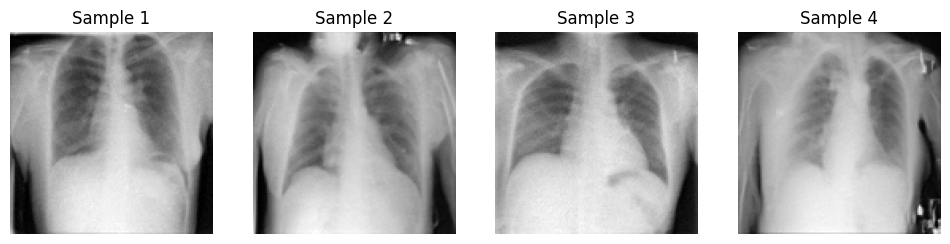

In [93]:
import torch
from diffusers import DDIMPipeline, DDIMScheduler, UNet2DModel
import matplotlib.pyplot as plt
from safetensors.torch import load_file

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Initialize the model architecture (same as training)
model = UNet2DModel(
    sample_size=128,   # match your training image size
    in_channels=1,
    out_channels=1,
    layers_per_block=3,
    block_out_channels=(128,128,256, 256, 512, 512),
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
).to(device)

# 2. Load the state dict from the safetensors file
state_dict = load_file("Pre-built Diffusion (epoch=50) X-ray/diffusion_pytorch_model.safetensors")
model.load_state_dict(state_dict)
model.eval()

torch.cuda.empty_cache()

# 3. Initialize DDIM scheduler and pipeline for faster, higher quality sampling
scheduler = DDIMScheduler(num_train_timesteps=2000)
pipeline = DDIMPipeline(unet=model, scheduler=scheduler).to(device)

# 4. Generate samples with DDIM and classifier-free guidance (CFG)
num_samples = 4
num_inference_steps =30 # DDIM works well with fewer steps


with torch.no_grad():
    generated_images = pipeline(
        num_inference_steps=num_inference_steps,
        batch_size=num_samples
    ).images

# 5. Plot generated images
plt.figure(figsize=(12, 3))
for i, img in enumerate(generated_images):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"Sample {i+1}")
plt.show()


In [97]:
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim
import numpy as np

# 1. Convert generated images (PIL) to tensors in [0,1]
to_tensor = transforms.ToTensor()
gen_batch = torch.stack([to_tensor(img) for img in generated_images])  # [10, 1, 128, 128]

# 2. Denormalize real images from [-1,1] to [0,1]
def denorm(img):
    return ((img * 0.5) + 0.5).clamp(0, 1)
# Load one batch of real images from your dataloader
real_batch = next(iter(dataloader))  # shape: [batch_size, 1, 128, 128]
real_batch_01 = denorm(real_batch)

# 3. Compute SSIM
ssim_scores = []
for real, fake in zip(real_batch_01, gen_batch):
    real_np = real.squeeze().cpu().numpy()
    fake_np = fake.squeeze().cpu().numpy()
    score = ssim(real_np, fake_np, data_range=1.0)
    ssim_scores.append(score)

print(f"Mean SSIM: {np.mean(ssim_scores):.4f}")


Mean SSIM: 0.4641
